## Burn Scar Analysis with PACE and EMIT Data

Author: Skye Caplan (NASA, SSAI), Erik Bolch (USGS)

Last updated: 03/05/2026

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/
[emit-data-access]: https://nasa.github.io/VITALS/python/Exploring_EMIT_L2A_RFL.html

## Summary

This notebook will use the data downloaded from `01_Colocate_PACE_EMIT_data.ipynb` and preprocessed from `02_Align_PACE_EMIT_Grids.ipynb` to calculate the difference in normalized burn ratio (dNBR) over Southern California in response to fires which occurred in January 2025. We will demonstrate the complementary nature of PACE and EMIT observations, and how we can use their different temporal and spatial resolutions to our advantage. 

## Learning Objectives

At the end of this notebook, you will know how to:
- FILL OUT

## Contents
1. [Setup](#1.-Setup)
2. 

## 1. Setup

Begin by importing all of the packages used in this notebook.

In [48]:
import os
import cartopy
import rasterio 
import cf_xarray 
import numpy as np 
import xarray as xr 
import rioxarray as rio
import geopandas as gpd
import cartopy.crs as ccrs 
import matplotlib.pyplot as plt 

os.chdir(os.path.abspath(os.path.join(get_ipython().starting_dir, os.pardir)))
from modules import pace_tools as pace
from modules import emit_tools as emit

import warnings
warnings.filterwarnings('ignore')

In the previous notebook tutorial, `02_Align_PACE_EMIT_Grid.ipynb`, we gridded, subset, and saved PACE and EMIT surface reflectance datasets to a region of interest around the January 2025 Southern California wildfires. Those data will be used for this tutorial, so please go through that content to generate the datasets for this tutorial if you have not already. If you have, you'll recall we exported the subset data to the `subset_data` directory - if you chose to export to your own directory, please replace the paths in the next cell with your path to the same files.

Since our data are already gridded, we won't need to use the EMIT or PACE tools to open and project them again. Instead, we can just load them as `xarray` datasets.

In [49]:
emit_paths = ["emit_pace/subset_data/emit_prefire.nc",
              "emit_pace/subset_data/emit_postfire.nc"]
oci_paths = [ "emit_pace/subset_data/oci_prefire.nc",
              "emit_pace/subset_data/oci_postfire.nc"]

emit_prefire = xr.open_dataset(emit_paths[0])
emit_postfire = xr.open_dataset(emit_paths[1])
oci_prefire = xr.open_dataset(oci_paths[0])
oci_postfire = xr.open_dataset(oci_paths[1])

### 2. Preparing Data for NBR
For this case study, we'll be investigating fires that occurred in December - February of 2024-2025 in Grampians National Park, Victoria, Australia using the Normalized Burn Ratio (NBR). NBR is a multispectral vegetation index that neither EMIT nor PACE puts out as a product, but can be calculated with their surface reflectance bands using the equation below:
$$NBR = \frac{\rho_{NIR} - \rho_{SWIR}}{\rho_{NIR}+\rho_{SWIR}}$$

Where $\rho_{\lambda}$ is the reflectance at a certain wavelength. The difference in NBR (dNBR) in time can be used to delineate burn scars in an area. dNBR is calculated as: $$dNBR = NBR_{prefire} - NBR_{postfire}$$

We've defined a function below to calculate the NBR with our two datasets.

In [50]:
def calc_nbr(ds, wvl_var=None):
    """
    Calculates Normalized Burn Ratio given reflectance data
    Args:
        ds - reflectance dataset with wavelength info as a coordinate
        wvl_var - str name of wavelength variable. Will attempt to find it if
                  none given
    Returns:
        nbr - NBR dataset
    """
    # Get wavelength dimension name for selection
    for dim in list(ds.dims):
        if "wavelength" in dim:
            wvl_var = dim
            break
        else:
            continue
    
    # Calculate NBR
    if wvl_var is None:
        print("Could not find wavelength variable, please provide the variable name in the function call")
        return None
    else:
        nir = ds.sel({f"{wvl_var}":870}, method="nearest")
        swir = ds.sel({f"{wvl_var}":2131}, method="nearest")
        nbr = ((nir - swir) / (nir + swir))
        nbr_ds = xr.Dataset(data_vars={"nbr":nbr}, 
                            coords={"latitude":nbr["latitude"].data,
                                    "longitude":nbr["longitude"].data})
        nbr_ds["nbr"].attrs["long_name"] = "Normalized Burn Ratio"
        return nbr_ds

In [51]:
oci_prefire_nbr = calc_nbr(oci_prefire["rhos"])
oci_postfire_nbr = calc_nbr(oci_postfire["rhos"])
emit_prefire_nbr = calc_nbr(emit_prefire["reflectance"])
emit_postfire_nbr = calc_nbr(emit_postfire["reflectance"])

We're almost ready to calculate the dNBR from PACE and EMIT. Before we can do this, we need to ensure the pre- and post-fire datasets from each instrument are the same shape so they can be successfully subtracted from one another. If their shapes differ, we can use `rioxarray`'s `reproject_match()` tool to quickly reproject one granule with the same resolution onto the other. 

<div class="alert alert-warning">
Note: I think you can use reproject match for ds's with different res, so should clarify the explanation above
</div>

In [52]:
def check_shapes(ds1, ds2):
    """ 
    Checks that shapes of two ds's are the same. If not, prints which dataset is bigger.
    Args:
        ds1, ds2 - two datasets to compare
    """
    if ds1.shape == ds2.shape:
        print(f"The two input datasets are the same shape: {ds1.shape}")
    else:
        print(f"Dataset 1 shape: {ds1.shape}\nDataset 2 shape: {ds2.shape}")

check_shapes(oci_prefire_nbr["nbr"], oci_postfire_nbr["nbr"])

The two input datasets are the same shape: (63, 55)


In [53]:
check_shapes(emit_prefire_nbr["nbr"], emit_postfire_nbr["nbr"])

Dataset 1 shape: (1603, 1540)
Dataset 2 shape: (1661, 1540)


The PACE datasets are the same shape, but those from EMIT are slightly different in the latitude dimension. We'll extend pre-fire scene to match the post-fire scene to preserve the extra rows of data from the latter granule. 

In [54]:
# Must set CRS first before reprojecting
emit_prefire_nbr = emit_prefire_nbr.rio.write_crs("epsg:4326")
emit_postfire_nbr = emit_postfire_nbr.rio.write_crs("epsg:4326")

emit_prefire_nbr = emit_prefire_nbr.rio.reproject_match(emit_postfire_nbr)
emit_prefire_nbr = emit_prefire_nbr.rename({"x":"longitude", "y":"latitude"})

check_shapes(emit_prefire_nbr["nbr"], emit_postfire_nbr["nbr"])

The two input datasets are the same shape: (1661, 1540)


Now, the dNBR can be calculated to assess burn scars in the area.

In [55]:
oci_dnbr = oci_prefire_nbr - oci_postfire_nbr
oci_dnbr = oci_dnbr.rename({"nbr":"dnbr"})
oci_dnbr["dnbr"].attrs["long_name"] = "Difference in NBR"

emit_dnbr = emit_prefire_nbr - emit_postfire_nbr
emit_dnbr = emit_dnbr.rename({"nbr":"dnbr"})
emit_dnbr["dnbr"].attrs["long_name"] = "Difference in NBR"

Explanation of reading and dissolving shapefile for just our national park of interest

In [56]:
grampians = gpd.read_file("emit_pace/grampians_shp/PARKRES.shp")
grampians = grampians[grampians["NAME"] == "Grampians National Park"]
grampians = grampians[["geometry","NAME", "AREA_SRC", "TOTAL_AREA", "HECTARES", "AREASQM"]]
grampians["geometry"] = grampians["geometry"].buffer(0.005)
grampians = grampians.dissolve(by="NAME", aggfunc="sum")

Now plot

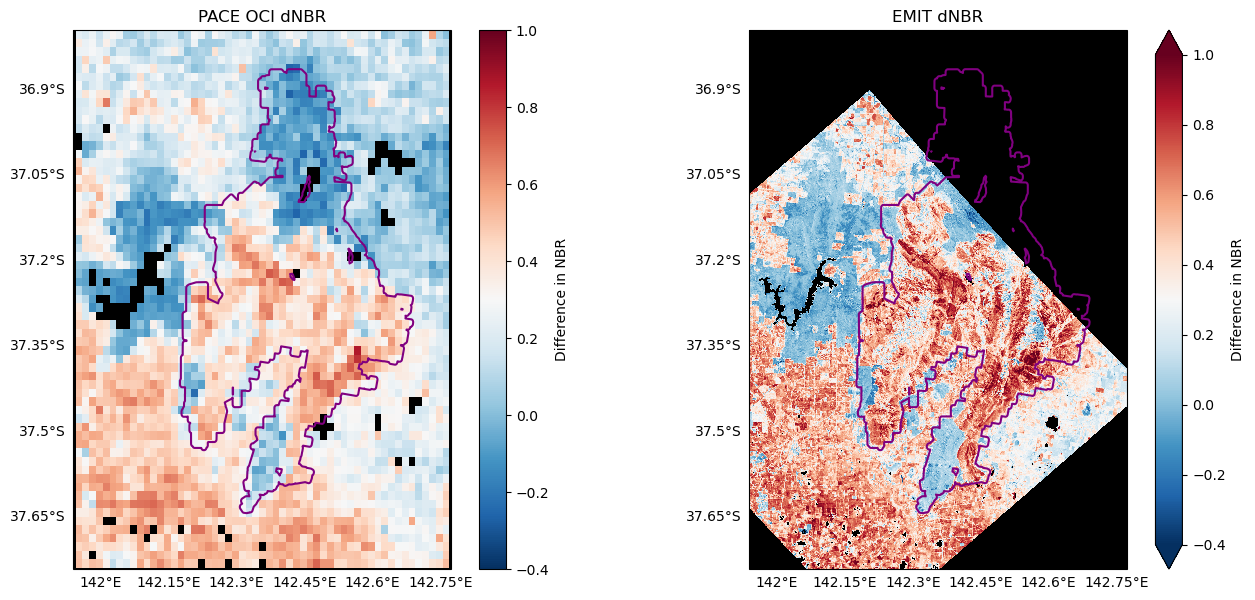

In [57]:
fig, ax = plt.subplots(1,2, figsize=(16, 7), sharex=True, sharey=True,
                       subplot_kw={"projection": ccrs.PlateCarree()})
oci_dnbr.dnbr.plot(vmin=-0.4, vmax=1, cmap="RdBu_r", ax=ax[0])
emit_dnbr.dnbr.plot(vmin=-0.4, vmax=1, cmap="RdBu_r",ax=ax[1])
ax[0].gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25, alpha=0)
ax[0].set_facecolor('k')
ax[0].set_title("PACE OCI dNBR")
ax[1].gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25, alpha=0)
ax[1].set_facecolor('k')
ax[1].set_title("EMIT dNBR")
grampians.plot(ax=ax[0], facecolor='none', edgecolor='purple', linewidth=1.5)
grampians.plot(ax=ax[1], facecolor='none', edgecolor='purple', linewidth=1.5)
plt.show()

Great! Lots of burned area in the park, but lots of burned area outside of that as well. Can use PACE to see how these areas evolved between our two bounding days of Nov. 14th and Mar 19th, while we can use EMIT for fractional cover, detailed looks at burn severity and burned area, etc. 

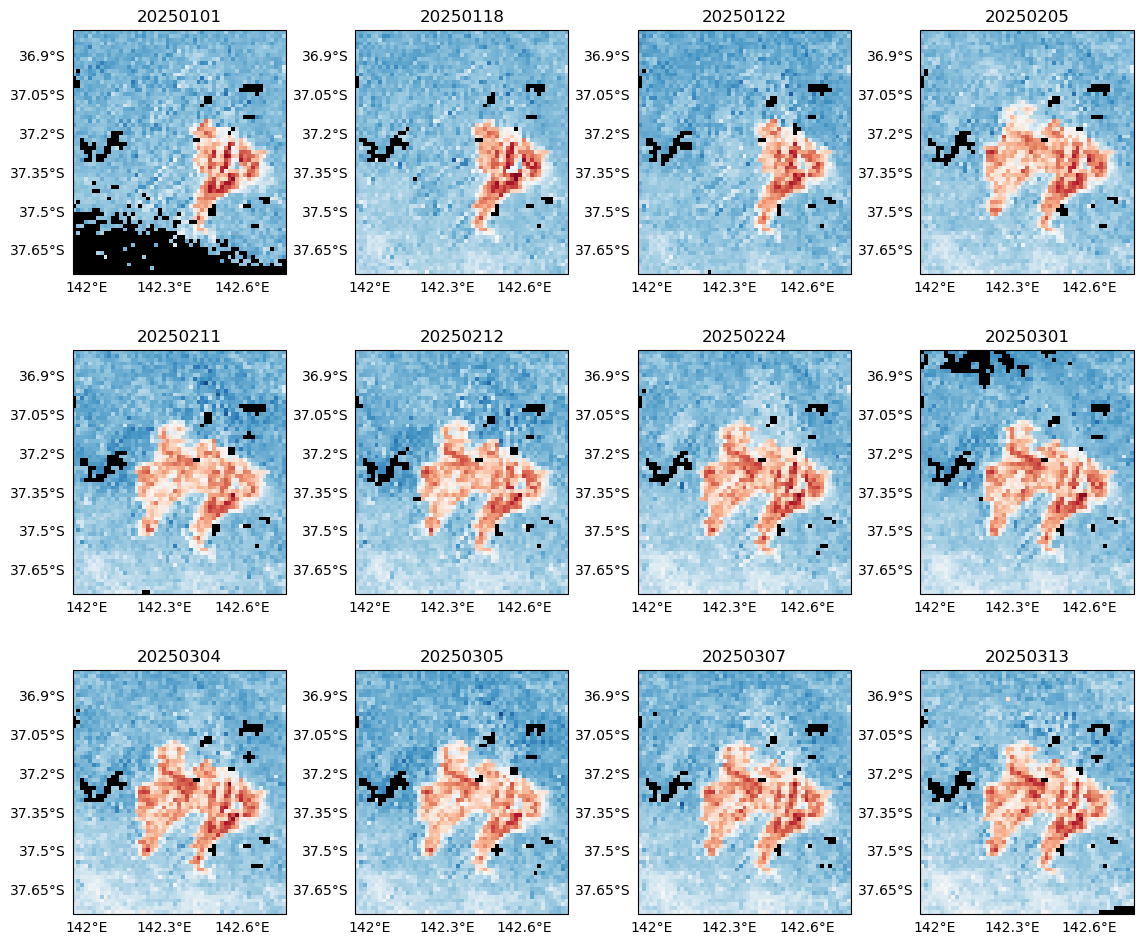

In [86]:
import glob
from os.path import basename
subs = sorted(glob.glob("emit_pace/ts_data/subs/*.nc"))

oci_dec_prefire = xr.open_dataset(subs[0])
oci_dec_prefire_nbr = calc_nbr(oci_dec_prefire["rhos"])

rows = 3
cols = 4
fig, ax = plt.subplots(rows, cols, sharex=True, sharey=True, 
                       figsize=(12,12), subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout(pad=5)
ax = ax.flatten()
ax_ct = 0

for sub in subs[1:]:
    postfire_ds = xr.open_dataset(sub)
    postfire_ds = calc_nbr(postfire_ds["rhos"])
    dnbr = oci_dec_prefire_nbr - postfire_ds
    dnbr = dnbr.rename({"nbr":"dnbr"})
    dnbr["dnbr"].attrs["long_name"] = "Difference in NBR"

    dnbr["dnbr"].plot(vmin=-0.4, vmax=1, cmap="RdBu_r", ax=ax[ax_ct], add_colorbar=False)
    ax[ax_ct].set_facecolor('k')
    ax[ax_ct].gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25, alpha=0)
    ax[ax_ct].set_title(f"{basename(sub)[9:17]}")
    ax_ct += 1
plt.show()
    
    

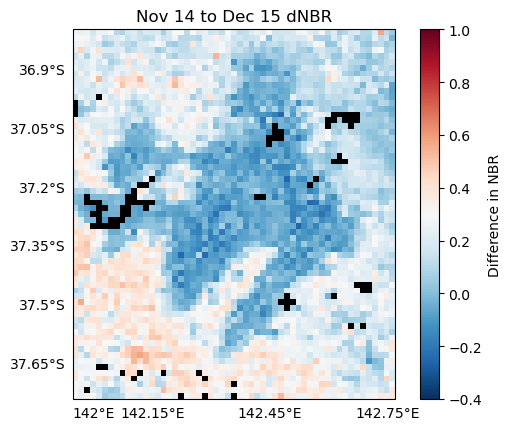

In [87]:
# So either a fire or a harvest?? can't tell from imagery
nov_dec_dnbr_oci = oci_prefire_nbr - oci_dec_prefire_nbr 

nov_dec_dnbr_oci = nov_dec_dnbr_oci.rename({"nbr":"dnbr"})
nov_dec_dnbr_oci["dnbr"].attrs["long_name"] = "Difference in NBR"
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
nov_dec_dnbr_oci["dnbr"].plot(vmin=-0.4, vmax=1, cmap="RdBu_r", ax=ax)
ax.set_facecolor("k")
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25, alpha=0)
ax.set_title(f"Nov 14 to Dec 15 dNBR")
plt.show()

Cells below for exploring 

In [ ]:
#import earthaccess
#from shapely import geometry

# Pre:
# dec 15

# Post:
# jan 01 jan 18 jan 22 feb 05 (burning, but mostly clear) feb 11 feb 12 feb 24 mar 01 mar 04 mar 05 mar 07 mar 13

#tspan = [('2025-02-12','2025-02-12'),
#         ('2025-02-24','2025-02-24'),('2025-03-01','2025-03-01'),
#         ('2025-03-04','2025-03-05'),('2025-03-07','2025-03-07'),
#         ('2025-03-13','2025-03-13'),]
#roi_bounds = (141.9385, -37.74163, 142.77324, -36.79961)
#
#bbox = geometry.box(*roi_bounds, ccw=True)
#roi = list(bbox.exterior.coords)
#gdf = gpd.GeoDataFrame(index=[0], crs='epsg:4326', geometry=[bbox])

In [ ]:
#grans = []
#for t in tspan:
#    results = earthaccess.search_data(
#        short_name=["PACE_OCI_L2_SFREFL"],
#        polygon=roi,
#        temporal=t,
#    )
#    grans.extend(results)
#
#len(grans)

8

In [ ]:
#bbox = [141.9385, -37.74163, 142.77324, -36.79961]
#resolution = (0.015, 0.015)
#
#for g in grans:
#    path = earthaccess.download(g, local_path="emit_pace/ts_data")
#    whole = pace.open_l2(path[0])
#    whole = pace.mask_ds(whole, flag=["CLDICE","LAND"], reverse=[False,True])
#    whole = pace.grid_data(whole, resolution=resolution)
#    sub = whole.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})
#    sub.to_netcdf(path[0].replace("ts_data","ts_data/subs"))

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

CLDICE mask applied
LAND mask applied


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

CLDICE mask applied
LAND mask applied


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

CLDICE mask applied
LAND mask applied
